#### Bank Marketing Dataset: Customer Segmentation with Clustering

This notebook demonstrates how to download, preprocess, cluster, and visualize the UCI Bank Marketing dataset for customer segmentation using unsupervised learning (KMeans clustering).

---

#### Set Up Notebook Environment
Install and import the necessary packages.

In [1]:
# Install required packages (uncomment if running for the first time)
# %pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#### Load the Bank Marketing Dataset
- load it into a pandas DataFrame.

In [2]:
# Load the dataset from local file
local_path = r"D:\Makesh\Working\AI\RPS\Day02-8th Nov\datasets\bank-additional-full.csv"
df = pd.read_csv(local_path, sep=';')
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
4670,28,admin.,single,high.school,no,no,no,telephone,may,wed,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no
21367,31,technician,married,unknown,no,no,no,cellular,aug,mon,...,3,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no
13722,28,admin.,single,university.degree,no,yes,no,telephone,jul,thu,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
21371,32,technician,single,university.degree,no,no,no,cellular,aug,mon,...,7,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no
429,31,services,married,high.school,unknown,no,no,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

#### Data Preprocessing
- Encode categorical variables
- Scale numerical features
- Prepare data for clustering

In [6]:
# Separate features into categorical and numerical
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove the target column if present
target_col = 'y'

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

In [12]:
# Encode categorical features
encoded_df = df.copy()

for col in categorical_cols:
    encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col])

# Scale numerical features
scaler = StandardScaler()
encoded_df[numerical_cols] = scaler.fit_transform(encoded_df[numerical_cols])

# Prepare data for clustering (exclude target)
X = encoded_df.drop(columns=[target_col])
X.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,cluster
0,1.533034,3,1,0,0,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,1
1,1.628993,7,1,3,1,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0
2,-0.290186,7,1,3,0,2,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0
3,-0.002309,0,1,1,0,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,1
4,1.533034,7,1,3,0,0,2,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0
5,0.477486,7,1,2,1,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0
6,1.820911,0,1,5,0,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,3
7,0.093650,1,1,7,1,0,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,3
8,-1.537652,9,2,5,0,2,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0
9,-1.441693,7,2,3,0,2,0,1,6,1,...,-0.565922,0.195414,-0.349494,1,0.648092,0.722722,0.886447,0.71246,0.33168,0


#### Clustering with KMeans
- Find optimal number of clusters (elbow method)
- Fit KMeans and assign cluster labels

d:\ProgramFiles\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ProgramFiles\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\ProgramFiles\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ProgramFiles\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

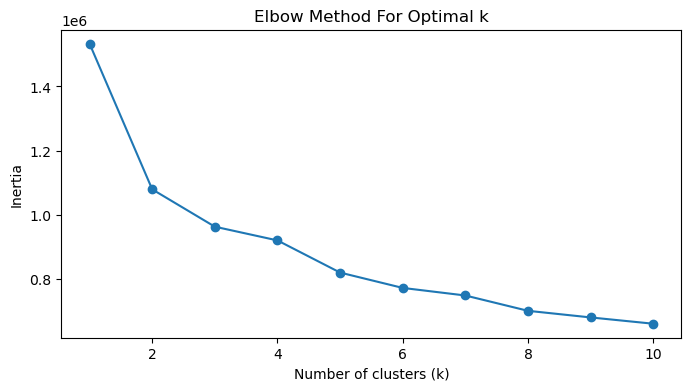

In [8]:
# Find the optimal number of clusters using the elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [9]:
# Fit KMeans with the chosen number of clusters (e.g., k=4)
k = 4
kmeans   = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels to the original dataframe
df['cluster'] = clusters
df['cluster'].value_counts()

cluster
1    14132
0    13161
3     8559
2     5336
Name: count, dtype: int64

#### Visualize Clusters
- Use PCA to reduce dimensions for visualization
- Plot clusters in 2D

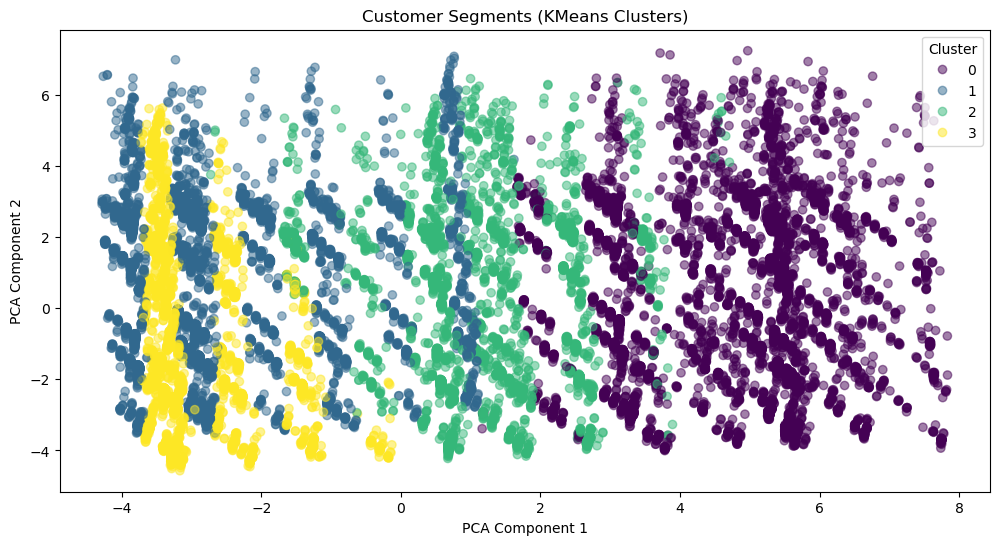

In [10]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (KMeans Clusters)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

#### Visualize Clusters with t-SNE and UMAP
- t-SNE and UMAP can reveal more structure in high-dimensional data when projected to 2D.

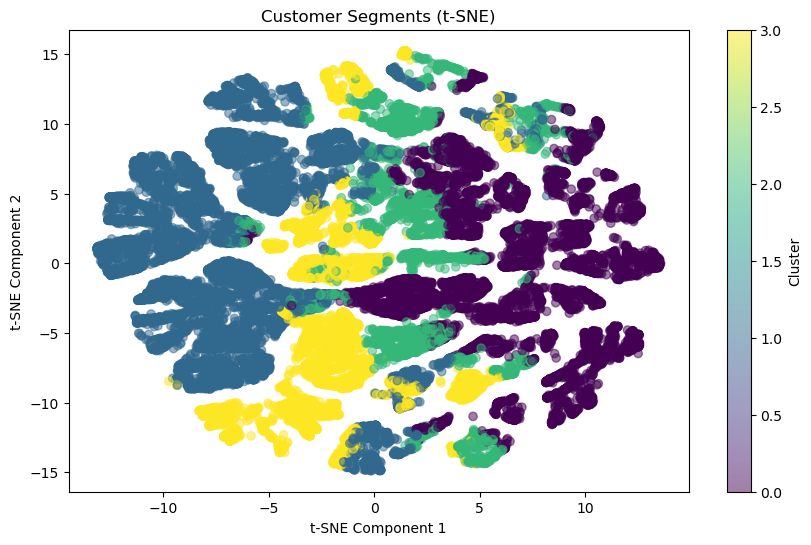

In [11]:
# t-SNE visualization
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, max_iter=300)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Customer Segments (t-SNE)')
plt.colorbar(label='Cluster')
plt.show()

In [20]:
#pip install umap-learn

d:\python_envs\ds_ml_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


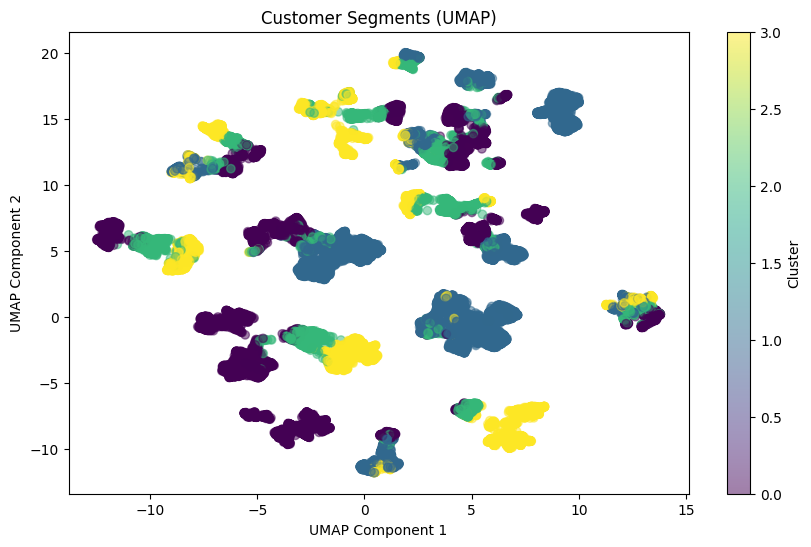

In [21]:
# UMAP visualization
# If umap-learn is not installed, uncomment the next line:
# %pip install umap-learn
import umap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('Customer Segments (UMAP)')
plt.colorbar(label='Cluster')
plt.show()

#### Cluster Profiling
- Analyze the characteristics of each cluster to understand customer segments.

In [23]:
# Calculate mean values of features for each cluster
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
cluster_profile.T  # Transpose for easier viewing

cluster,0,1,2,3
age,37.840666,40.859680,45.486882,38.595981
duration,255.030849,260.771370,263.451462,255.962612
campaign,2.562951,2.585975,2.450712,2.617245
pdays,960.300509,976.803000,945.565030,952.705807
previous,0.174835,0.140178,0.232946,0.186821
emp.var.rate,0.134032,0.205159,-0.257571,0.009791
cons.price.idx,93.577623,93.655014,93.469383,93.507897
cons.conf.idx,-40.328706,-41.105314,-40.124213,-40.010737
euribor3m,3.664360,3.741415,3.333546,3.536114
nr.employed,5168.558901,5172.374278,5153.282046,5164.454387


**Cluster Profiling Inference:**

- Cluster 2: Highest average age, lowest employment variation rate, lowest consumer price index, and lowest euribor3m and nr.employed. This group may represent older customers in a less favorable economic environment—possibly more conservative or less engaged.
- Cluster 1: Slightly older, highest emp.var.rate, cons.price.idx, cons.conf.idx (most negative), and euribor3m. This group may be more affected by economic changes or more active during periods of higher economic activity.
- Cluster 0 and 3: Similar in age, with average values for most features. These may represent the “average” customer segments, with cluster 3 having slightly lower emp.var.rate and euribor3m.
- Duration, campaign, pdays, previous: Similar across clusters, indicating similar marketing contact patterns.

**Business inference:**
- Cluster 2 may need different marketing strategies, possibly focusing on stability and trust.
- Cluster 1 could be targeted with products for more economically active or risk-tolerant customers.
- Clusters 0 and 3 may be the general population, suitable for broad campaigns.

For deeper insights, analyze categorical features (e.g., job, marital, education) by cluster, or visualize distributions for each feature per cluster.

#### Visualize Feature Distributions per Cluster
- Plot the distribution of selected features for each cluster to better understand segment characteristics.

C:\Users\bhupe\AppData\Local\Temp\ipykernel_6256\2160253315.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


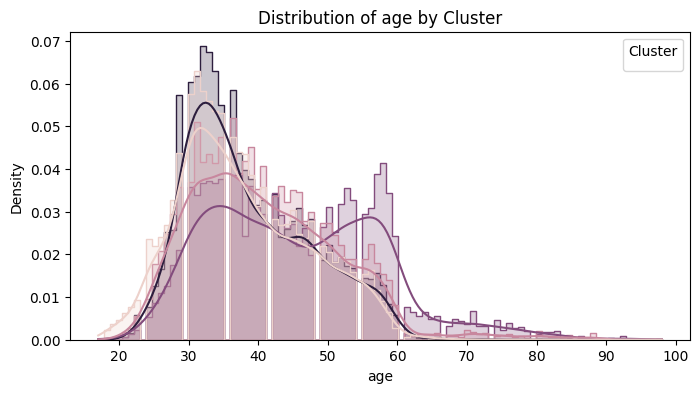

C:\Users\bhupe\AppData\Local\Temp\ipykernel_6256\2160253315.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


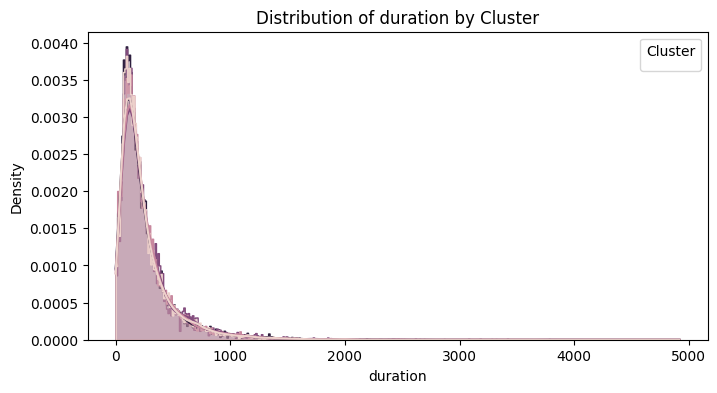

C:\Users\bhupe\AppData\Local\Temp\ipykernel_6256\2160253315.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


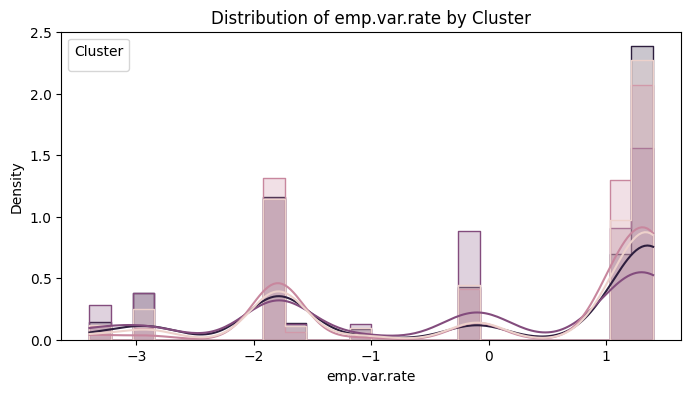

C:\Users\bhupe\AppData\Local\Temp\ipykernel_6256\2160253315.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


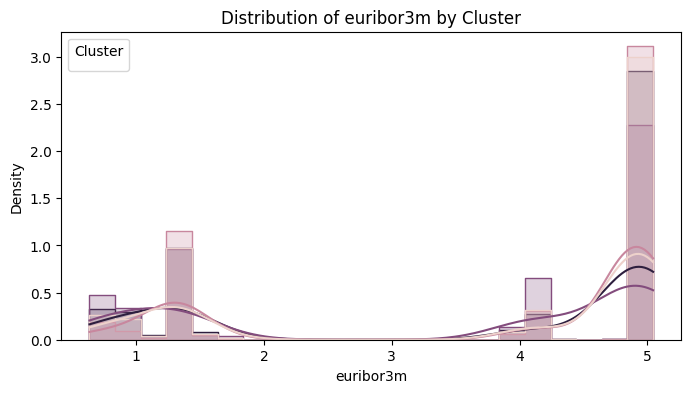

In [24]:
# Visualize distributions of selected features per cluster
features_to_plot = ['age', 'duration', 'emp.var.rate', 'euribor3m']

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, hue='cluster', kde=True, element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by Cluster')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend(title='Cluster')
    plt.show()

#### Using Clusters for Targeted Marketing and Business Actions

Once customer segments are identified through clustering, you can:

- **Personalize Marketing Campaigns:** Design specific offers, messages, or channels for each cluster based on their unique characteristics and preferences.
- **Product Recommendations:** Suggest relevant banking products (e.g., loans, credit cards, savings plans) to each segment.
- **Customer Retention:** Identify at-risk segments and proactively engage them with retention strategies.
- **Resource Allocation:** Allocate sales and support resources more efficiently by focusing on high-value or high-potential clusters.
- **Business Strategy:** Inform product development, pricing, and service improvements by understanding the needs and behaviors of each segment.

Clustering enables data-driven decision-making, helping banks and financial institutions maximize customer value and improve business outcomes.